# SciPy: Probability

In [10]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, plt, sns

## 1. Fundamental

Probability is the branch of mathematics concerning numerical descriptions of how likely an event is to occur, or how likely it is that a proposition is true. The probability of an event is a number between 0 and 1. All phenomena in nature are random events, so if we can know the possibility of this event, we can predict the likelihood of it happening in the future or we can make decisions depending on it.

### 1.1. Combinatorics
There are a number of ways choosing $k=2$ elements from a set $\{A,B,C\}$ having $n=3$ elements: [permutation] are for ordered subsets and [combination] for unordered subsets.

|Type|Vietnamese|Order?|Repeat?|Formula|
|:-|:-|:-:|:-:|:-:|
|Permutation (all items)|Hoán vị|&check;||$n!$|
|Permutation ($k$ of $n$)|Chỉnh hợp|&check;||$P_k^n$|
|Permutation with repetition|Chỉnh hợp lặp|&check;|&check;|$n^k$|
|Combination|Tổ hợp|||$C_k^n$|
|Combination with repetition|Tổ hợp lặp||&check;|$C_k^{n+k-1}$|

$$C_k^n=\dfrac{n!}{k!(n-k)!}\,;\quad P_k^n=\dfrac{n!}{(n-k)!}$$

[permutation]: https://en.wikipedia.org/wiki/Permutation
[combination]: https://en.wikipedia.org/wiki/Combination

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd

from scipy.special import perm, comb

In [29]:
def count(n, k, order=True, repeat=True):
    if order and repeat:
        return n ** k
    elif order and not repeat:
        return perm(n, k)
    elif not order and repeat:
        return comb(n + k - 1, k)
    elif not order and not repeat:
        return comb(n, k)

count(4, 2)

16

### 1.2. Basic concepts

#### Experiment and event
- [Experiment] (or trial) is any procedure that can be infinitely repeated and has a well-defined set of possible outcomes, known as the sample space. An experiment is said to be random if it has more than one possible outcome.
- The result of the experiment is called [event]. There are three types of event in real life: random, certain and impossible events.
- The [probability] of an event shows how likely that event is to occur. The formula for the probability of an event $A$ is the fraction between the number of favorable outcomes over the total of outcomes.

[Experiment]: https://en.wikipedia.org/wiki/Experiment_(probability_theory)
[event]: https://en.wikipedia.org/wiki/Event_(probability_theory)
[probability]: https://en.wikipedia.org/wiki/Probability

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd
from scipy.special import perm, comb

:::{admonition} Case
:class: tip

Draw 4 cards from a [standard 52-card deck]. What is the probability of getting exactly 2 Spades?

:::

[standard 52-card deck]: https://en.wikipedia.org/wiki/Standard_52-card_deck

In [8]:
no_spades = 13
no_non_spades = 52 - no_spades

support = comb(no_spades, 2) * comb(no_non_spades,2)
total = comb(52, 4)

prob = support / total
print(f'{prob:.2%}')

21.35%


#### Conditional probability
Conditional probability $P(A\mid B)$ describes the probability of an event ($A$) *given that* another event ($B$) has already happened. For example, suppose you draw a card from a standard deck. Let ($B$) be the event "the first card drawn is a King". If you keep that card (so you don't put it back), there are now 51 cards left in the deck, and only 3 of them are Kings. That changes the probability of event $A$, "the second card drawn is a king" to $P(A\mid B)=3/51$.

::::{admonition} Case: Monty Hall problem
:class: tip

You are a contestant on a game show. There are three doors: behind one door is a car (the prize you want), and behind the other two doors are goats (which you don't want). You pick a door, say Door 1. The host, who knows what's behind the doors, opens another door, say Door 3, which has a goat. He then asks you if you want to switch your choice to Door 2. You have watched this show many times and know that the host always opens a door with a goat and always offers you the chance to switch. Is it to your advantage to switch your choice?

:::{mermaid}
:align: center

graph TD
   Start((Start)) -->|1/3| C1[Car is Door 1]
   Start -->|1/3| C2[Car is Door 2]
   Start -->|1/3| C3[Car is Door 3]
   C1 -->|Monty opens D2 or D3| S1[Switch: LOSE]
   C2 -->|Monty MUST open D3| S2[Switch: WIN]
   C3 -->|Monty MUST open D2| S3[Switch: WIN]
   %% Styles with borders removed
   style S1 fill:indianred,color:#fff,stroke-width:0px
   style S2 fill:#4CAF50,color:#fff,stroke-width:0px
   style S3 fill:#4CAF50,color:#fff,stroke-width:0px
   
:::

The important thing to notice is that the host always offers you to change, no manipulation. With this assumption, the tree diagram above shows when you switch, you win 2 out of 3 times. You can express this conclusion using conditional probability:

$$\begin{aligned}
P(\text{Win}) &= 1/3 \\
P(\text{Win}\mid\text{Switch}) &= 2/3
\end{aligned}$$

::::

#### Multiplication rule
Multiplication rule describes the probability of both events $A$ and $B$ happening, denoted $P(A\cap B)$. The formula when $A$ and $B$ are dependent is:

$$P(A\cap B) = P(A)\cdot P(B\mid A)$$

When $A$ and $B$ are independent, $P(B\mid A)=P(B)$, then the multiplication rule becomes:

$$P(A\cap B) = P(A)\cdot P(B)$$

:::{admonition} Case
:class: tip

Drawing two cards from a deck, what is the probability of getting two Kings in a row?
- Scenario 1: You return the first card back in the deck before drawing the second card. The deck remains exactly the same for both draws. The calculation:

$$P(\text{King and King}) = \frac{4}{52} \times \frac{4}{52} = \frac{16}{2704} \approx 0.59\%$$

- Scenario 2: You draw a card and keep it, the deck will be changed (only has 51 cards) for the second draw. Assume you caught a King in the first try, there is now only 3 Kings left. The calculation:

$$P(\text{King and King}) = \frac{4}{52} \times \frac{3}{51} = \frac{12}{2,652} \approx 0.45\%$$

:::

#### Addition rule
Addition rule describes the probability of either event $A$ or event $B$ happening, denoted $P(A\cup B)$:

$$P(A\cup B)=P(A)+P(B)-P(A\cap B)$$

The relationship between $A$ and $B$ can be described using [exclusivity](https://en.wikipedia.org/wiki/Mutual_exclusivity). Two events are mutually exclusive if they do not occur in the same trial. If $A$ and $B$ are mutually exclusive, then $P(A\cap B)=0$, we can ignore this term.

::::{admonition} Case
:class: tip

Drawing a card from a deck, what is the probability of getting a Queen or a Heart?

:::{image} ../image/chap_02/addition_rule.png
:height: 250px
:align: center
:::

$$
\begin{aligned}
P(\text{Queen or Heart})
&= P(\text{Queen}) + P(\text{Heart}) - P(\text{Queen of Heart}) \\
&= \frac{4}{52} + \frac{13}{52} - \frac{1}{52} \approx 30.77\%
\end{aligned}
$$

::::

### 1.3. Bayes' theorem
[Bayes' theorem] is an important formula in Probability and Statistics; it's easy to write down (it's simply a consequence of the multiplication rule) but can be abstract to fully understand. This section summarizes [3Blue1Brown's article], which explains the formula in an intuitive way.

[Bayes' theorem]: https://en.wikipedia.org/wiki/Bayes%27_theorem
[3Blue1Brown's article]: https://www.3blue1brown.com/lessons/bayes-theorem

::::{admonition} Case: Steve the librarian
:class: tip

Steve is very shy and withdrawn, invariably helpful but with very little interest in people or in the world of reality. A meek and tidy soul, he has a need for order and structure, and a passion for detail. Is Steve more likely to be a librarian or a farmer?

Most people reply quickly that Steve is more likely to be a librarian than a farmer. How people think is usually like this: for every 10 librarians there are like 4 introverts, and for every 10 farmers there are only 1 introvert. It's easy to compare and make a conclusion.

But almost no one incorporate information about the ratio of farmers to librarians into their judgments. At the time this problem is first introduced in the book "Think fast and slow", there are about 20 farmers for every 1 librarian. This means if you say 10 librarians, you are saying 200 farmers.

:::{image} ../image/chap_02/introvert_fit.png
:height: 200px
:align: center
:::

This overwhelmingly large ratio of farmers to librarians greatly increases the chances that Steve is a farmer, even though his description seems librarian-ish. In other words, even if you think a librarian is 4 times as likely as a farmer to fit this description, that’s not enough to overcome the fact that there are way more farmers.

::::

Bayes' theorem is relevant in situations where you have some hypothesis (Steve is a librarian), and you see some evidence (Steve is a "meek and tidy soul"), and you want to know the probability that the hypothesis holds *given that* the evidence is true. Mathematically, this is oftenly written as $P(H|E)$ or $P(\text{Hypothesis}\mid\text{Evidence})$, which the calculation can be broken down as follows:
- The [prior] $P(H)$, the proportion of librarians in the population (the population contains only librarians and farmers).
- The [likelihood] $P(E|H)$, the probability that someone is introvert given that he is a librarian.
- $P(H)P(E|H)$ is the proportion of a introvert librarians in the population.
- Similarly, we also care about $P(\neg H)P(E|\neg H)$, the proportion of introvert farmers in the population.
- $P(E)=P(H)P(E|H)+P(\neg H)P(E|\neg H)$ is the proportion of introvert people in the population. Oftentimes, the full form is needed for calculation.
- The [posterior] $P(H|E)$, which is what we want, is calculated as:

$$P(H|E)=\frac{P(H)P(E|H)}{P(H)P(E|H)+P(\neg H)P(E|\neg H)}$$

This formula is Bayes' theorem. It can be nicely visualized with a diagram, which is encouraged for memorizing.

:::{image} ../image/chap_02/bayes_theorem_diagram.png
:height: 200px
:align: center
:::

[prior]: https://en.wikipedia.org/wiki/Prior_probability
[likelihood]: https://en.wikipedia.org/wiki/Likelihood_function
[posterior]: https://en.wikipedia.org/wiki/Posterior_probability

:::{admonition} Case
:class: tip

A small company has rated 75% of its employees as satisfactory and 25% as unsatisfactory. A survey shows that 80% of the satisfactory workers are seniors, while 60% of the unsatisfactory workers are seniors. If a senior is hired, what is the probability that worker will be unsatisfied?
- $E$: an employee is senior
- $H_1=H$: an employee is unsatisfied
- $H_0=\neg H$: an employee is satisfied

:::

In [ ]:
p_H1 = 0.25
p_E_given_H1 = 0.6

p_H0 = 0.75
p_E_given_H0 = 0.8

p_E_H1 = p_H1 * p_E_given_H1
p_E_H0 = p_H0 * p_E_given_H0

p_H1_given_E = p_E_H1 / (p_E_H1 + p_E_H0)

print(f'{p_H1_given_E:.2%}')

## 2. Distributions
The distribution is a mathematical function that calculates the probability of different possible outcomes for an experiment. The [`scipy.stats`] sub-module supports the following popular distributions:
- Binomial distribution: `binom(n, p)`
- Poisson distribution: `poisson(mu)`
- Uniform distribution: `uniform(loc, scale)`
- Normal distribution: `norm(loc, scale)`
- t-distribution: `t(df)`
- F-distribution: `f(dfn, dfd)`
- Chi-squared distribution: `chi2(df)`
- Cauchy distribution: `cauchy(loc, scale)`
- Exponential distribution: `expon(scale)`
- Logistic distribution: `logistic(loc, scale)`
- Beta distribution: `beta(a, b)`
- Gamma distribution: `gamma(a)`

Each distribution object has the following methods:
- `rvs(size)` returns a random variable follow the given distribution
- `pmf(k)` (for discrete distributions) or `pdf(x)` (for continuous distributions) returns the probability of a given value $P(\mathbf{x}=c)$
- `cdf(x)` (cumulative distribution function) returns probability $P(\mathbf{x}\leq c)$ and its inverse `ppf(x)` (percent point function)
- `sf(x)` (survival function) returns $P(\mathbf{x}>c) = 1-P(\mathbf{x}\leq c)$ and its inverse `isf(x)` (inverse survival function)
- `mean()` `median()` `var()` `std()` return the corresponding statistics
- `stats(moments='mvsk')` returns the mean, standard deviation, skewness and kurtosis

[`scipy.stats`]: https://docs.scipy.org/doc/scipy/reference/stats.html

### 2.1. Discrete distribution

In [0]:
import sys; sys.path.append('..')
from util import np, pd, stats, plt, sns

#### Binomial distribution
[Binomial distribution] is a discrete distribution, it is defined as the probability of $k$ $(k\in\mathbb{N})$ number of occurrences of an event in $n$ $(n\in\mathbb{N})$ trials. Each trial has exactly two possible outcomes: success with the probability of $p$ $(p\in [0;1])$ and failure with the probability of $1-p$. The PMF of binomial distribution is:

$$f(k;n) = \frac{n!}{k!(n-k)!} p^k (1-p)^{n-k}$$

If $\mathbf{x}$ is a binomial distributed random variable: $\mathbf{x}\sim \text{Bin}(n,p)$, then $\mathbf{x}$ has the mean of $np$ and the variance of $np(1-p)$. If there is only a single trial ($n=1$), the distribution is known as [Bernoulli distribution].

For example, given a balanced coin (so that each flip has a probability of $p=0.5$ head and $1-p=0.5$ tail). Flip the coin $n=6$ times. Binomial distribution can be used to find:
- The probability of 4 heads
- The probability of 3 heads or less
- The probability of more than 3 heads
- The expected number of heads

[Binomial distribution]: https://en.wikipedia.org/wiki/Binomial_distribution
[Bernoulli distribution]: https://en.wikipedia.org/wiki/Bernoulli_distribution

In [0]:
stats.binom(n=6, p=0.5).pmf(4)

In [0]:
stats.binom(n=6, p=0.5).cdf(3)

In [0]:
stats.binom(n=6, p=0.5).sf(3)

In [0]:
stats.binom(n=6, p=0.5).mean()

#### Poisson distribution
[Poisson distribution] is the other discrete distribution in this topic. It is defined as the probability of $k$ $(k\in\mathbb{N})$ number of events occurring in an unit of time, assume that the events are independent and the average number of events per unit of time should must be a known constant $\lambda$. The PMF of Poisson distribution is:

$$f(k;\lambda) = \frac{\lambda^k e^{-\lambda}}{k!}$$

If $\mathbf{x}$ is a Poisson distributed random variable: $\mathbf{x}\sim \text{Poi}(\lambda)$, then both the mean and the variance of $\mathbf{x}$ equal $\lambda$.

For example, a police department receives an average of $\lambda=5$ calls per hour. Poisson distribution can be used to calculate the probability of receiving $k=2$ calls in a randomly selected hour.

[Poisson distribution]: https://en.wikipedia.org/wiki/Poisson_distribution

In [0]:
stats.poisson(mu=5).pmf(2)

### 2.2. Continuous distribution

#### Exponential distribution
[Exponential distribution] is a continuous distribution, and is strongly related to Poisson distribution. It describes the probability of time between two events, given the average number of events per unit of time is $\lambda$ (the average amount of time to the next event can be calculated as $1/\lambda$). The PDF of exponential distribution is:

$$f(x;\lambda) = \lambda e^{-\lambda x}$$

If $\mathbf{x}$ is exponential distributed random variable: $\mathbf{x}\sim \text{Exp}(\lambda)$, then $\mathbf{x}$ has the mean of $\displaystyle{\frac{1}{\lambda}}$ and the variance of $\displaystyle{\frac{1}{\lambda^2}}$.

For example, a police department receives an average of $\lambda=5$ calls per hour. Exponential distribution can be used to calculate the probability that the next call comes after 15 minutes ($x=0.25$).

[Exponential distribution]: https://en.wikipedia.org/wiki/Exponential_distribution

In [0]:
# scale = 1/lambda
stats.expon(scale=1/5).pdf(0.25)

In [0]:
data = [0.5, 1, 1.5]
fig, ax = plt.subplots(figsize=(10,5))
for lamda in data:
    x = np.linspace(0, 5, 100)
    y = stats.expon(scale=1/lamda).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\lambda={lamda}$' for lamda in data])
plt.show()

#### Normal distribution
[Normal distribution] (also known as Gaussian distribution) is the most important distribution in Statistics since many continuous data in real life follow a normal distribution such as human weights, IQ scores, blood pressures and shoe sizes. It is also the foundation of many other distributions as well as the Central Limit Theorem. The PDF of normal distribution is:

$$f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}\cdot\exp{\left(-\frac{1}{2}{\frac{(x-\mu)^2}{\sigma^2}}\right)}$$

If $\mathbf{x}$ is a normal distributed random variable: $\mathbf{x}\sim \mathcal{N}(\mu,\sigma)$, then $\mathbf{x}$ has the mean of $\mu$ and the variance of $\sigma^2$. In the case $\mathbf{x}\sim \mathcal{N}(0,1)$, the variable is now standard normal distributed.

[Normal distribution]: https://en.wikipedia.org/wiki/Normal_distribution

In [0]:
data = [(0, 1), (0, 0.5), (2, 0.5)]
fig, ax = plt.subplots(figsize=(10,5))
for mu, sigma in data:
    x = np.linspace(-4, 4, 100)
    y = stats.norm(mu, sigma).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\mu={mu}$, $\sigma={sigma}$' for mu, sigma in data])
plt.show()

#### Logistic distribution
[Logistic distribution] can be used in growth models and logistic regression; its shape is very similar to normal distribution. Logistic distribution has two parameters: $\mu$ (location) and $s$ (scales). Consecutively, the PDF of logistic distribution is:

$$f(x;\mu,s) = \frac{\exp{\left(-\dfrac{x-\mu}{s}\right)}}{s\left(1+\exp{\left(-\dfrac{x-\mu}{s}\right)}\right)^{2}}$$

If $\mathbf{x}$ is a logistic distributed random variable: $\mathbf{x}\sim \text{Logistic}(\mu,s)$, then $\mathbf{x}$ has the mean of $\mu$ and the variance of $\displaystyle{\frac{s^2 \pi^2}{3}}$.

[Logistic distribution]: https://en.wikipedia.org/wiki/Logistic_distribution

In [0]:
data = [(0, 1), (0, 2), (4, 2)]
fig, ax = plt.subplots(figsize=(10,5))
for mu, s in data:
    x = np.linspace(-12, 18, 100)
    y = stats.logistic(mu, s).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\mu={mu}$, $s={s}$' for mu, s in data])
plt.show()

#### t-distribution
Let $\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_D$ be independent samples drawn from the distribution $\mathcal{N}(\mu,\sigma)$, then the random variable $\dfrac{\hat \mu_{d}-\mu}{\hat \sigma_{d}/\sqrt{n}}$ has a [t-distribution] with $\nu=D-1$ degree of freedom. When sample size is large $D>30$, the difference between t-distribution and normal distribution is negligible, therefore it can be used as a normal approximation when population variance is unknown. The PDF of t-distrbution is:

$$
f(x;\nu) = 
\frac {\Gamma\left(\frac{\nu+1}{2}\right)} {\Gamma\left(\frac{\nu}{2}\right)\sqrt{\nu\pi}}
{\left(1+\frac{x^2}{\nu}\right)}^{-\frac{\nu+1}{2}}
$$

Notice that $\Gamma(x)$ is the gamma function, which is the extension of factorial function to real numbers.

If $\mathbf{x}$ is a t-distributed random variable: $\mathbf{x}\sim \text{t}(\nu)$, then $\mathbf{x}$ has the mean of $0$ and the variance of $\nu/(\nu-2)$.

[t-distribution]: https://en.wikipedia.org/wiki/Student%27s_t-distribution

In [0]:
data = [1, 2, 10]
fig, ax = plt.subplots(figsize=(10,5))
for nu in data:
    x = np.linspace(-5, 5, 100)
    y = stats.t(nu).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\nu={nu}$' for nu in data])
plt.show()

#### Chi-square distribution
Let $\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_D$ are independent standard normal distributed variables, then the sum of their squares has a [chi-square distribution] with $D$ degrees of freedom. Chi-square distribution is mainly used in hypothesis testing. The PDF of chi-square distribution is:

$$f(x;k) = \frac {1}{\Gamma \left(\frac{k}{2}\right)2^{\frac{k}{2}}}\cdot x^{\frac{k}{2}-1}\cdot e^{-\frac{x}{2}}$$

If $\mathbf{x}$ is a chi-square distributed random variable: $\mathbf{x}\sim \chi^2(\nu)$, then $\mathbf{x}$ has the mean of $k$ and the variance of $2k$.

[chi-square distribution]: https://en.wikipedia.org/wiki/Chi-square_distribution

In [0]:
data = [1, 3, 5, 7]
fig, ax = plt.subplots(figsize=(10,5))
for k in data:
    x = np.linspace(0, 8, 100)
    y = stats.chi2(k).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$k={k}$' for k in data])
ax.set_ylim((0, 0.5))
plt.show()

#### F-distribution
Given two variable $\mathbf{x}_1\sim \chi^2(d_1)$ and $\mathbf{x}_2\sim \chi^2(d_2)$, then the variable $\dfrac{d_2\mathbf{x}_1}{d_1\mathbf{x}_2/}$ has a [F-distribution] with two shape parameters $d_1$, $d_2$ (degrees of freedom). The PDF of F-distribution is:

$$f(x; d_1, d_2) = 
\frac{1}{x\,\text{B}\left(\frac{d_1}{2},\frac{d_2}{2}\right)}
\sqrt{\frac{(d_1x)^{d_1}\,d_2^{d_2}}{(d_1x+d_2)^{d_1+d_2}}}$$

If $\mathbf{x}$ is a F-distributed random variable: $\mathbf{x}\sim \text{F}(d_1,d_2)$, then $\mathbf{x}$ has the mean of $\dfrac{d_2}{d_2-2}$ and the variance of $\dfrac{2d_2^2\,(d_1+d_2-2)}{d_1(d_2-2)^2(d_2-4)}$.

[F-distribution]: https://en.wikipedia.org/wiki/F-distribution

In [0]:
data = [(5,2), (10,10), (30,30)]
fig, ax = plt.subplots(figsize=(10,5))
for d1, d2 in data:
    x = np.linspace(0, 5, 100)
    y = stats.f(d1, d2).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$d_1={d1}$, $d_2={d2}$' for d1, d2 in data])
plt.show()

#### Beta distribution
[Beta distribution] is defined in the interval $[0;1]$ with two shape parameters, $\alpha$ and $\beta$. The PDF of beta distribution is:

$$f(x;\alpha,\beta) = \frac{x^{\alpha-1}\,(1-x)^{\beta-1}}{\text{B}(\alpha,\beta)}$$

Notice that $\text{B}(\alpha,\beta)$ is the beta function which is defined based on the gamma function. The denominator in this function works as a normalization to ensure the area under the curve is 1.

If $\mathbf{x}$ is a beta distributed random variable: $\mathbf{x}\sim \text{Beta}(\alpha,\beta)$, then $\mathbf{x}$ has the mean of $\displaystyle{\frac{\alpha}{\alpha+\beta}}$ and the variance of $\displaystyle{\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}}$.

[Beta distribution]: https://en.wikipedia.org/wiki/Beta_distribution

In [0]:
data = [(2,9), (2,5), (5,2), (7,7)]
fig, ax = plt.subplots(figsize=(10,5))
for a, b in data:
    x = np.linspace(0, 1, 100)
    y = stats.beta(a, b).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\alpha={a}$, $\beta={b}$' for a, b in data])
plt.show()

#### Gamma distribution
[Gamma distribution] has the exponential distribution and the chi-square distribution as special cases. It has a shape parameter $k$ and a scale parameter $\theta$. The PDF of gamma distribution is:

$$f(x;k,\theta) = 
\frac{x^{k-1}e^{-\frac{x}{\theta}}}{\Gamma(k)\,\theta^k}$$

If $\mathbf{x}$ is a gamma distributed random variable: $\mathbf{x}\sim \Gamma(k,\theta)$, then $\mathbf{x}$ has the mean of $k\theta$ and the variance of $k\theta^2$.

[Gamma distribution]: https://en.wikipedia.org/wiki/Gamma_distribution

In [0]:
data = [(2,2), (5,1), (9,0.5), (7,1)]
fig, ax = plt.subplots(figsize=(10,5))
for k, theta in data:
    x = np.linspace(0, 20, 100)
    y = stats.gamma(a=k, scale=theta).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$k={k}$, $\theta={theta}$' for k, theta in data])
plt.show()

### 2.3. Multivariate distribution 

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, plt, sns

#### Gaussian distribution
[Multivariate Gaussian distribution] is the generalization of univariate Gaussian distribution into high dimensional space. $D$ variables $\mathbf{X}=\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_D$ following a normal distribution is denoted $\mathbf{X}\sim\mathcal{N}(\boldsymbol{\mu},\boldsymbol{\Sigma})$. Here:
- $\boldsymbol{\mu}\in\mathbb{R}^D$ is the mean vector, the element $\mu_d$ is the mean of the respective variable $\mathbf{x}_d$
- $\boldsymbol{\Sigma}\in\mathbb{R}^{D\times D}$ is the covariance matrix, where the elements in the diagonal show the variances and elements elsewhere show the pair-wise covariance.

[Multivariate Gaussian distribution]: https://en.wikipedia.org/wiki/Multivariate_normal_distribution

In [0]:
mu = [0, 0]
sigma = np.array([
    [6.8, 5.0],
    [5.0, 7.4]
])
dist = stats.multivariate_normal(mu, sigma)
x, y = np.mgrid[-7:7:.1, -7:7:.1]
data = np.dstack([x, y])
z = dist.pdf(data)

fig, ax = plt.subplots()
ax.contourf(x, y, z, cmap='Blues')
ax.axis('scaled')
plt.show()

### 2.4. Central Limit Theorem
In probability theory, the [Central Limit Theorem] (CLT) establishes that, with large amount of random variables, CLT that even if the data distribution is not normal, the distribution of the means of the samples drawn from it will be normal.

Below are the practical implications of knowing that means are normally distributed:
- Use the mean’s normal distribution to assign confidence intervals.
- Perform any statistical test under the sun which uses sample mean.

[Central Limit Theorem]: https://en.wikipedia.org/wiki/Central_limit_theorem

In [4]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, plt, sns

In [2]:
means = []
samples = []
for i in range(0, 1000):
    samples.append(np.random.exponential(scale=1.0, size=20))
    means.append(np.mean(samples[i]))

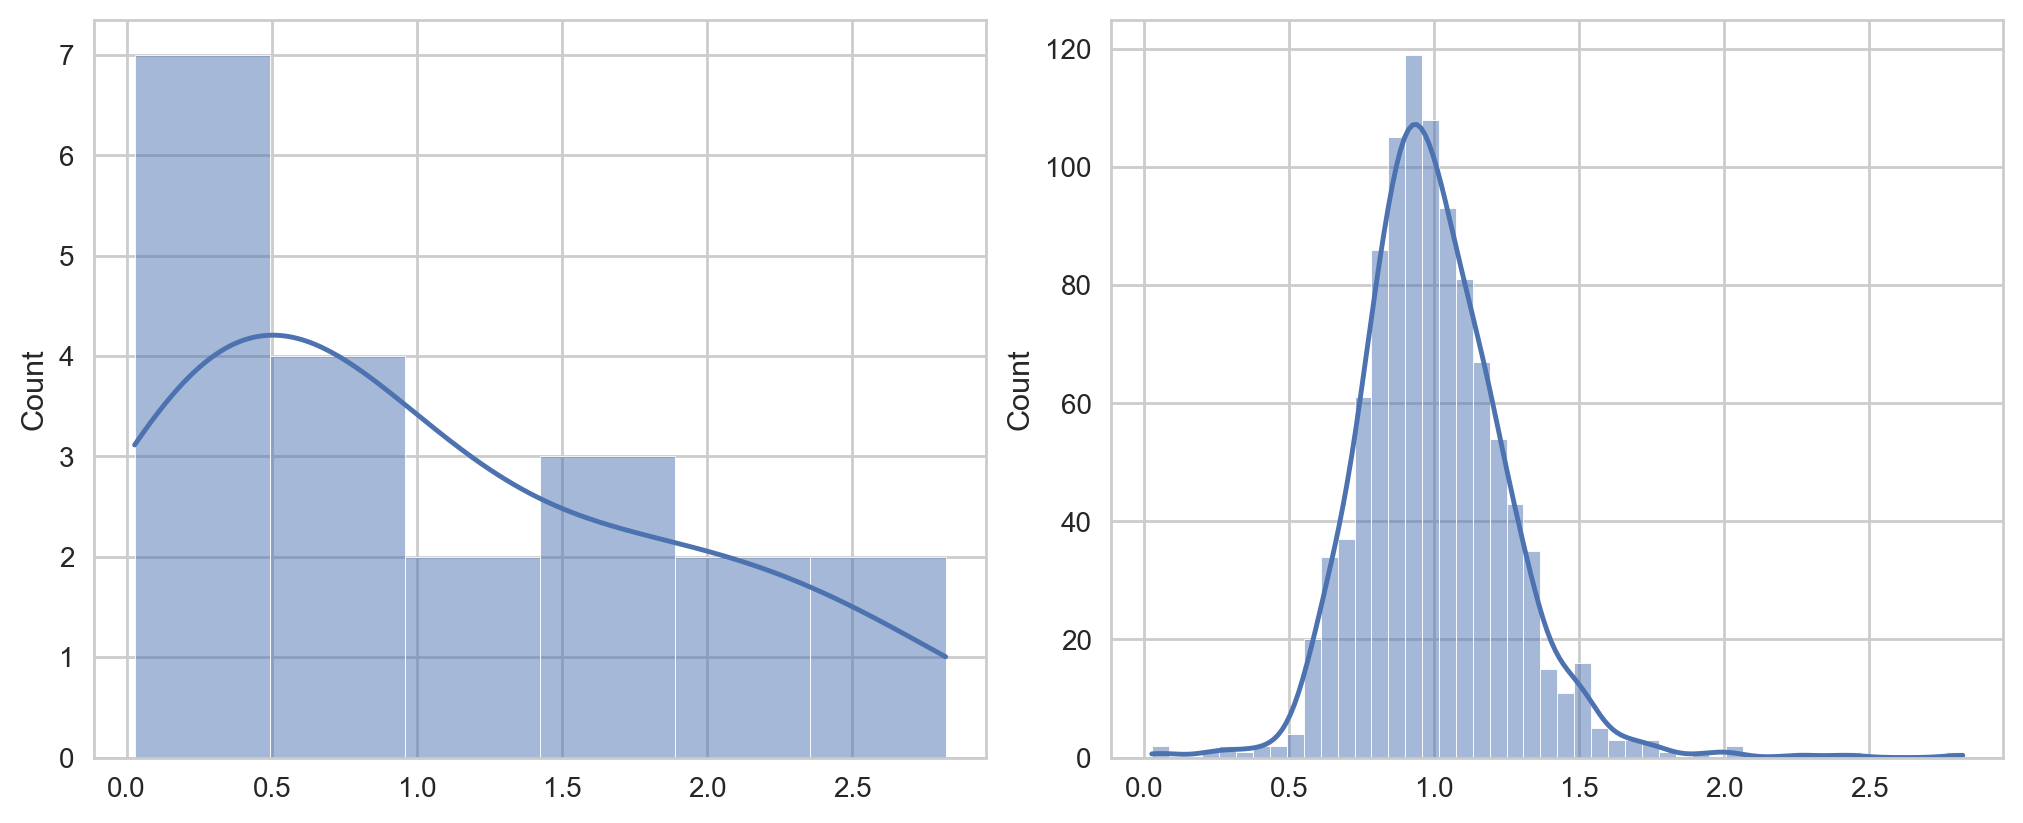

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(samples[0], ax=ax[0], kde=True, edgecolor='w')
sns.histplot(np.append(samples[0], means), ax=ax[1], kde=True, edgecolor='w')
plt.show()

## Resources
- illinois.edu - [Multi-event Probability: Addition Rule](https://discovery.cs.illinois.edu/learn/Prediction-and-Probability/Multi-event-Probability-Addition-Rule/)